# **Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import zipfile
import os
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Dense , Dropout , Activation , Flatten
from keras.layers import Conv2D , MaxPooling2D , GlobalMaxPooling2D , BatchNormalization

# **Functions**

In [ ]:
def acc_plot(model):
    plt.figure(figsize = (10,6))
    sns.set_style('whitegrid')
    plt.plot(model.history['accuracy'] , color = '#E74C3C' , marker = 'o')
    plt.plot(model.history['val_accuracy'] , color = '#641E16' , marker = 'h')
    plt.title('Accuracy comparison between Validation and Train data' , fontsize = 15)
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train' , 'Test'] , loc = 'lower right')
    plt.show()

In [ ]:
def loss_plot(model):
    plt.figure(figsize = (10,6))
    sns.set_style('whitegrid')
    plt.plot(model.history['loss'] , color = 'Purple' , marker = 'o')
    plt.plot(model.history['val_loss'] , color = 'Orange' , marker = 'h')
    plt.title('Loss comparison between Validation and Train data' , fontsize = 15)
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train' , 'Test'] , loc = 'lower right')
    plt.show()

# **Data Preprocessing**

## **Import Dataset**

In [ ]:
zip_path = "Dataset.zip"
extract_path = "Dataset"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

dataset_path = extract_path

## **Show Dataset**

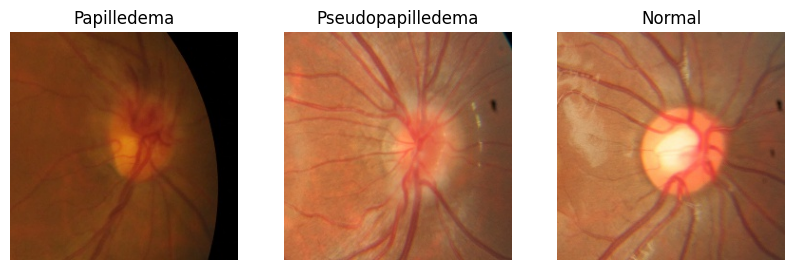

In [ ]:
class_names = ['Papilledema', 'Pseudopapilledema', 'Normal']

plt.figure(figsize=(10, 10))
for i, class_name in enumerate(class_names):
    class_path = os.path.join(dataset_path, class_name)
    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)
    plt.subplot(1, len(class_names), i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.show()

In [ ]:
image_size = (240, 240)
data = []
labels = []

for label, class_name in enumerate(class_names):
    class_path = os.path.join(dataset_path, class_name)
    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)
        image = Image.open(image_path).resize(image_size)
        data.append(np.array(image))
        labels.append(label)

data = np.array(data)
labels = np.array(labels)

print("Initial data shape")
print(f"Data shape: {data.shape}, labels shape: {labels.shape}")

Initial data shape
Data shape: (1369, 240, 240, 3), labels shape: (1369,)


## **Normalization**

In [ ]:
data = data / 255.0

## **Train-Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

print(f"X_train.shape: {X_train.shape}, X_test.shape: {X_test.shape}")

X_train.shape: (1095, 240, 240, 3), X_test.shape: (274, 240, 240, 3)


## **Check Imbalancing**

Data distribution: Counter({2: 624, 0: 241, 1: 230})


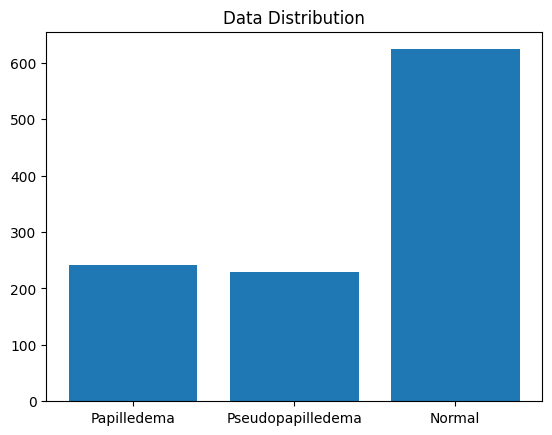

In [ ]:
class_counts = Counter(y_train)
print("Data distribution:", class_counts)

unique, counts = np.unique(y_train, return_counts=True)
plt.bar(class_names, counts)
plt.title("Data Distribution")
plt.show()

## **Balance Data**

In [ ]:
# Target data for each class
target_count = 624

balanced_X_train = []
balanced_y_train = []

for img, label in zip(X_train, y_train):
    balanced_X_train.append(img)
    balanced_y_train.append(label)

# Generate new data
datagen = ImageDataGenerator(horizontal_flip=True)

for class_label, count in class_counts.items():
    if count < target_count:
        class_images = X_train[y_train == class_label]
        images_to_generate = target_count - count

        for i in range(images_to_generate):
            img = np.expand_dims(class_images[i % count], 0)
            augmented_image = datagen.flow(img, batch_size=1)[0]
            balanced_X_train.append(augmented_image[0])
            balanced_y_train.append(class_label)

balanced_X_train = np.array(balanced_X_train)
balanced_y_train = np.array(balanced_y_train)


unique, counts = np.unique(balanced_y_train, return_counts=True)
print("Data distribution", dict(zip(unique, counts)))


Data distribution {0: 624, 1: 624, 2: 624}


# **Fine Tuning Models**

## **ResNet50**

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model

In [ ]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(240, 240, 3))

In [ ]:
# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
x = base_model.output
x = GlobalMaxPooling2D()(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
x = Dense(32, activation='relu')(x)
predictions = Dense(3, activation='softmax')(x)

In [ ]:
ResNet_model = Model(inputs=base_model.input, outputs=predictions)

In [ ]:
ResNet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
ResNet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 240, 240, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 246, 246, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 120, 120, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 120, 120, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 120, 120, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 122, 122, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 60, 60, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 60, 60, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 60, 60, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 60, 60, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 60, 60, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 60, 60, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 60, 60, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 60, 60, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 60, 60, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 23,860,419 (91.02 MB)

 Trainable params: 272,707 (1.04 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
ResNet_history = ResNet_model.fit(balanced_X_train , balanced_y_train , batch_size = 30 , epochs = 30 ,
              validation_data = (X_test , y_test_encoded) , shuffle = True)

Epoch 1/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 324s 9s/step - accuracy: 0.4725 - loss: 1.3985 - val_accuracy: 0.5657 - val_loss: 1.0070
Epoch 2/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 320s 9s/step - accuracy: 0.5827 - loss: 1.0023 - val_accuracy: 0.5657 - val_loss: 1.0113
Epoch 3/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 323s 9s/step - accuracy: 0.5736 - loss: 0.9825 - val_accuracy: 0.2372 - val_loss: 1.1354
Epoch 4/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 288s 8s/step - accuracy: 0.5001 - loss: 1.0328 - val_accuracy: 0.5657 - val_loss: 0.9787
Epoch 5/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 346s 9s/step - accuracy: 0.5379 - loss: 1.0054 - val_accuracy: 0.5657 - val_loss: 1.0384
Epoch 6/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 322s 8s/step - accuracy: 0.5686 - loss: 0.9829 - val_accuracy: 0.5657 - val_loss: 0.9989
Epoch 7/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 323s 9s/step - accuracy: 0.5821 - loss: 0.9769 - val_accuracy: 0.5657 - val_loss: 0.9563
Epoch 8/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 320s 8s/step - accuracy: 0.5613 - loss: 0.9664 - val_accuracy: 0.5657 - v

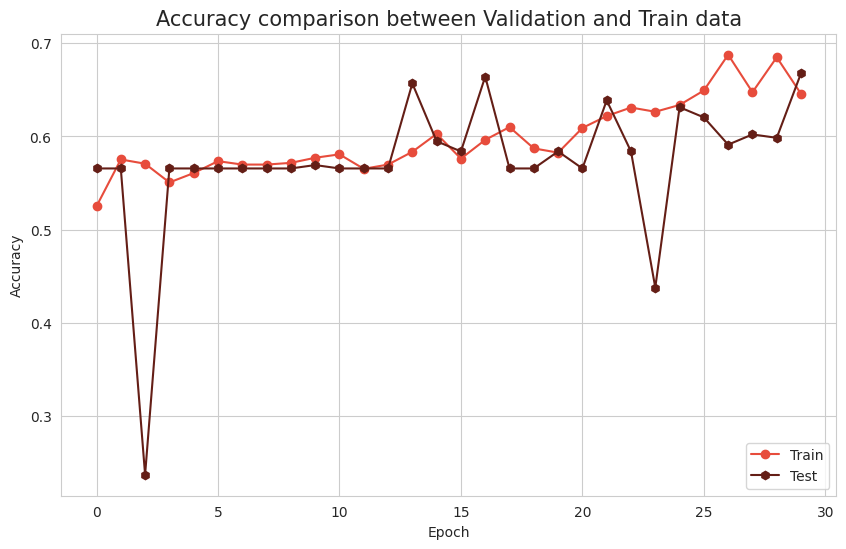

In [ ]:
acc_plot(ResNet_history)

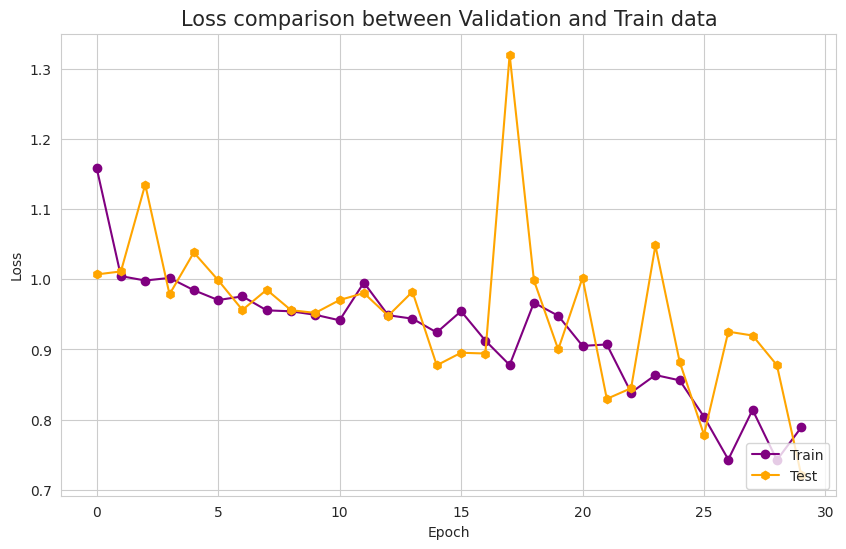

In [ ]:
loss_plot(ResNet_history)